In [1]:
#%load_ext autoreload
#%autoreload 2
import pandas as pd
import numpy as np
import pyrepseq as prs
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
import os
from scipy import stats
import utils
from joblib import Parallel, delayed
import cupy as cp
from scipy.stats import bootstrap
from typing import Literal
import pickle
import glob
import multiprocessing as mp
from collections import defaultdict
import itertools

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def save_data(data, output_path):
    """
    Save data to a pickle file

    Args:
        data: Data to save (typically a dictionary of DataFrames)
        output_path (str): Path where the pickle file will be saved

    Returns:
        None
    """
    print(f"Saving data to {output_path}...")

    # Create directory if it doesn't exist
    output_dir = os.path.dirname(output_path)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Save the data
    with open(output_path, 'wb') as f:
        pickle.dump(data, f)

/home/yipingzou2/.local/lib/python3.8/site-packages/Bio/__init__.py:118: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a setup.py file in an unexpected directory: /home/yipingzou2/.local/lib/python3.8/site-packages
  warnings.warn(
Matplotlib is building the font cache; this may take a moment.
/home/yipingzou2/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def return_pointwise_mutual_information(df, col1, col2, base=np.e, use_gpu=False):
    # 選擇使用 CuPy 或 NumPy
    xp = cp if use_gpu else np
    
    # 總樣本數
    n = len(df)
    
    # 使用 pandas value_counts 進行更快的計數
    p_x = df[col1].value_counts(normalize=True).to_dict()
    p_y = df[col2].value_counts(normalize=True).to_dict()
    
    # 使用 groupby 創建聯合分佈（更快）
    joint_counts = df.groupby([col1, col2]).size() / n
    
    # 根據底數選擇適當的對數函數
    if base == 2:
        log_func = xp.log2  # 使用底數為2的對數（bits）
    elif base == np.e:
        log_func = xp.log   # 使用自然對數（nats）
    elif base == 10:
        log_func = xp.log10 # 使用底數為10的對數
    
    # 將聯合概率轉換為數組進行批量計算
    joint_keys = list(joint_counts.keys())
    joint_probs = xp.array(joint_counts.values)
    non_zero_mask = joint_probs > 0
    
    # 獲取對應的邊緣概率
    px_values = xp.array([p_x[xi] for xi, _ in joint_keys])
    py_values = xp.array([p_y[yi] for _, yi in joint_keys])
    
    # 批量計算 MI 貢獻
    mi_contributions = joint_probs * log_func(joint_probs / (px_values * py_values))
    # 創建一個包含 PMI 值的字典
    pmi_dict = {key: value for key, value in zip(joint_keys, mi_contributions)}
    
    # 為原始 DataFrame 添加 pointwise 列
    df_result = df.copy()
    df_result['pointwise'] = df.apply(lambda row: pmi_dict.get((row[col1], row[col2]), 0), axis=1)
    
    return df_result[[col1, col2, 'pointwise']]

In [4]:
def get_corrected_for_different_samples_accelerated(df_dict, col1, col2=None, P=1000, alpha=0.05, sample_times=10, nested_resamples=50, 
                                random_state=0, base=np.e, n_jobs=-1, method: Literal["percentile", "basic"] = "basic",
                                use_gpu=False, statistic_type: Literal["mi", "entropy"] = "mi"):
    """
    Compare whether there is a significant difference in mutual information between different HLA types
    
    Parameters:
    df: The dataframe containing all data
    col1, col2: The names of the two columns to calculate mutual information
    P: Number of bootstrap samples
    alpha: Significance level for confidence intervals
    sample_times: Number of times to repeat sampling
    nested_resamples: Number of nested resamples for bootstrap
    random_state: Random seed for reproducibility
    base: Base for logarithm in mutual information calculation
    n_jobs: Number of parallel jobs
    
    Returns:
    Mean MI values, lower CI bounds, and upper CI bounds for each HLA type
    """
    # 1. 優化點1: 只過濾一次數據框
    individuals = list(df_dict.keys())
    
    # 獲取最小形狀
    min_shape = min(len(df_indi) for df_indi in df_dict.values())-50
   
    # 初始化結果存儲
    mi_all = np.zeros((sample_times, len(individuals)))
    
    # 優化點2: 為每次迭代設置不同但可預測的隨機種子
    for i in range(sample_times):
        # 為當前迭代設置隨機種子
        iter_seed = random_state + i
        np.random.seed(iter_seed)
        
        sampled_dfs = []
        if min_shape is not None:
            for indi in individuals:
                df_indi = df_dict[indi]
                if len(df_indi) > min_shape:
                    sampled_dfs.append(df_indi.sample(n=min_shape, weights=df_indi['Collapsed'].values, random_state=iter_seed))
                else:
                    sampled_dfs.append(df_dict[indi])
        else:
            for indi in individuals:
                sampled_dfs.append(df_dict[indi])

        def process_df(hla_df, seed):
            if method == "percentile":
                return utils.percentile_t_bootstrap_parallel(
                    hla_df, col1, col2, P=P, alpha=alpha, 
                    nested_resamples=nested_resamples, random_state=seed, 
                    base=base, n_jobs=1, use_gpu=use_gpu  # 在內部函數中設為1，避免嵌套並行化
                )
            else:
                return utils.basic_bootstrap_statistic(
                    hla_df, col1, col2, base=base, n_resamples = P, random_state=seed, use_gpu=use_gpu, statistic_type=statistic_type
                )
        
        # 為每個HLA類型計算使用不同但可預測的種子
        hla_seeds = [iter_seed + j for j in range(len(sampled_dfs))]
        
        # 並行計算所有HLA類型的MI
        results = Parallel(n_jobs=n_jobs)(
            delayed(process_df)(df_indi, seed) 
            for df_indi, seed in zip(sampled_dfs, hla_seeds)
        )
        
        # 解包結果
        for j, (mi, _, _) in enumerate(results):
            mi_all[i, j] = mi
            
    # Calculate mean MI for each HLA type
    mean_mi = np.mean(mi_all, axis=0)
    
    # Standard error of the mean for each HLA type
    sem = stats.sem(mi_all, axis=0)
    
    # t-critical value for the given alpha
    t_crit = stats.t.ppf(1 - alpha/2, sample_times - 1)
    
    # Calculate confidence intervals
    ci_lower = mean_mi - t_crit * sem
    ci_upper = mean_mi + t_crit * sem
    
    return mean_mi, ci_lower, ci_upper


In [3]:
# Load the entropy data
twins_entropy = pd.read_pickle("/mnt/d/TCRMI/results/twins/entropy.pickle")

# Calculate confidence intervals and means for each feature
ci_lower_all = {}
ci_upper_all = {}
entropy_means_all = {}

for feature in list(twins_entropy.keys()):
    entropy_values_array = np.array(list(twins_entropy[feature].values()))  # Shape: (n_samples, n_patients)
    
    # Calculate 95% confidence intervals for each patient
    confidence_level = 0.95
    alpha = 1 - confidence_level
    
    # Calculate mean and confidence intervals for each patient (across samples)
    entropy_means = np.mean(entropy_values_array, axis=0)  # Mean entropy for each patient
    entropy_std = np.std(entropy_values_array, axis=0, ddof=1)  # Standard deviation for each patient
    n_samples = entropy_values_array.shape[0]
    
    # Calculate confidence intervals using t-distribution
    t_critical = stats.t.ppf(1 - alpha/2, df=n_samples-1)
    margin_of_error = t_critical * (entropy_std / np.sqrt(n_samples))
    
    ci_lower = entropy_means - margin_of_error
    ci_upper = entropy_means + margin_of_error
    
    # Store the results in separate dictionaries
    entropy_means_all[feature] = entropy_means
    ci_lower_all[feature] = ci_lower
    ci_upper_all[feature] = ci_upper

# Set style for publication quality
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Define which features you want to plot and save (modify this list as needed)
selected_features = [
    # Add your specific features here, for example:
    'CDRL3_AA', 'CDRH3_AA','CDRH3_AA|CDRL3_AA','CDRL3_AA|CDRH3_AA'
]

# If you want to see all available features first:
print("Available features:")
for i, feature in enumerate(twins_entropy.keys()):
    print(f"  {i}: {feature}")

# Now plot the results
for feature in list(twins_entropy.keys()):
    entropy_values = entropy_means_all[feature]  # Use the calculated means
    ci_lower = ci_lower_all[feature]
    ci_upper = ci_upper_all[feature]

    # Prepare data with patient and condition separation
    patients = []
    conditions = []
    entropy_vals = []
    ci_low = []
    ci_high = []
    
    for i, df_name in enumerate(list(df_dict.keys())):
        # Extract patient ID and condition
        parts = df_name.split('_')
        patient = parts[0]  # A1, A2, B1, etc.
        condition = parts[1]  # naive, memory
        
        patients.append(patient)
        conditions.append(condition)
        entropy_vals.append(entropy_values[i])
        ci_low.append(ci_lower[i])
        ci_high.append(ci_upper[i])
    
    df_plot = pd.DataFrame({
        'Patient': patients,
        'Condition': conditions,
        'Entropy': entropy_vals,
        'CI_lower': ci_low,
        'CI_upper': ci_high,
        'Dataframe': list(df_dict.keys())
    })
    
    # Create color mapping for patients
    unique_patients = sorted(df_plot['Patient'].unique())
    colors = sns.color_palette("Set2", len(unique_patients))  # or "husl", "tab10"
    patient_color_map = dict(zip(unique_patients, colors))
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot points with patient-specific colors
    for i, row in df_plot.iterrows():
        color = patient_color_map[row['Patient']]
        marker = 'o' if row['Condition'] == 'naive' else '^'  # Different markers for conditions
        markersize = 8
        
        # Plot the point
        ax.scatter(i, row['Entropy'], color=color, marker=marker, s=markersize**2, 
                  alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
        
        # Add error bars
        ax.errorbar(i, row['Entropy'], 
                   yerr=[[row['Entropy'] - row['CI_lower']], [row['CI_upper'] - row['Entropy']]], 
                   color=color, capsize=4, capthick=1.5, alpha=0.7, zorder=2)
    
    # Customize the plot
    ax.set_xlabel('Patient and Condition', fontweight='bold')
    ax.set_ylabel('Entropy', fontweight='bold')
    ax.set_title(f'Entropy Values for {feature}\nwith 95% Confidence Intervals', 
                fontweight='bold', pad=20)
    
    # Set x-axis labels
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels([f"{row['Patient']}\n{row['Condition'].title()}" for _, row in df_plot.iterrows()], 
                       rotation=0, ha='center')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
    
    # Create custom legend
    legend_elements = []
    for patient in unique_patients:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=patient_color_map[patient], 
                                        markersize=8, label=f'Patient {patient}',
                                        markeredgecolor='black', markeredgewidth=0.5))
    
    # Add condition legend
    legend_elements.extend([
        plt.Line2D([0], [0], marker='o', color='gray', markersize=8, 
                  label='Naive', linestyle='None', alpha=0.7),
        plt.Line2D([0], [0], marker='^', color='gray', markersize=8, 
                  label='Memory', linestyle='None', alpha=0.7)
    ])
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1), 
             frameon=True, fancybox=True, shadow=True)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Add subtle background
    ax.set_facecolor('#fafafa')
    
    plt.tight_layout()
    
    # Save only if feature is in selected_features list
    if feature in selected_features:
        # Create filename-safe name
        safe_feature = feature.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
        fig.savefig(f"/mnt/d/TCRMI/figures/twins/{safe_feature}_entropy.pdf", transparent=True)
        print(f"Saved: {safe_feature}_entropy.pdf")

    plt.close()

Available features:
  0: CDRL3_AA
  1: CDRH3_AA
  2: VL
  3: VH
  4: JL
  5: JH
  6: CDRL3_AA|CDRH3_AA
  7: CDRH3_AA|CDRL3_AA
  8: VL|VH
  9: VH|VL
  10: JL|JH
  11: JH|JL
Saved: CDRL3_AA_entropy.pdf
Saved: CDRH3_AA_entropy.pdf
Saved: CDRL3_AA|CDRH3_AA_entropy.pdf
Saved: CDRH3_AA|CDRL3_AA_entropy.pdf


In [4]:
twin_mi = pd.read_pickle("/mnt/d/TCRMI/results/twins/mi.pickle")

# Calculate confidence intervals and means for each feature pair
ci_lower_all = {}
ci_upper_all = {}
mi_means_all = {}

for feature1, feature2 in list(twin_mi.keys()):
    mi_values_array = np.array(list(twin_mi[(feature1, feature2)].values()))  # Shape: (n_samples, n_patients)
    
    # Calculate 95% confidence intervals for each patient
    confidence_level = 0.95
    alpha = 1 - confidence_level
    
    # Calculate mean and confidence intervals for each patient (across samples)
    mi_means = np.mean(mi_values_array, axis=0)  # Mean MI for each patient
    mi_std = np.std(mi_values_array, axis=0, ddof=1)  # Standard deviation for each patient
    n_samples = mi_values_array.shape[0]
    
    # Calculate confidence intervals using t-distribution
    t_critical = stats.t.ppf(1 - alpha/2, df=n_samples-1)
    margin_of_error = t_critical * (mi_std / np.sqrt(n_samples))
    
    ci_lower = mi_means - margin_of_error
    ci_upper = mi_means + margin_of_error
    
    # Store the results in separate dictionaries
    mi_means_all[(feature1, feature2)] = mi_means
    ci_lower_all[(feature1, feature2)] = ci_lower
    ci_upper_all[(feature1, feature2)] = ci_upper

In [5]:
selected_pairs = [('VL', 'VH'), ('CDRL3_AA', 'CDRH3_AA'),
                  ('JL', 'JH'), ('VL', 'CDRH3_AA'), ('CDRL3_AA', 'VH')]
# Set style for publication quality
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Now plot the results
for feature1, feature2 in list(twin_mi.keys()):
    mi_values = mi_means_all[(feature1, feature2)]  # Use the calculated means
    ci_lower = ci_lower_all[(feature1, feature2)]
    ci_upper = ci_upper_all[(feature1, feature2)]

    # Prepare data with patient and condition separation
    patients = []
    conditions = []
    mi_vals = []
    ci_low = []
    ci_high = []
    
    for i, df_name in enumerate(list(df_dict.keys())):
        # Extract patient ID and condition
        parts = df_name.split('_')
        patient = parts[0]  # A1, A2, B1, etc.
        condition = parts[1]  # naive, memory
        
        patients.append(patient)
        conditions.append(condition)
        mi_vals.append(mi_values[i])
        ci_low.append(ci_lower[i])
        ci_high.append(ci_upper[i])
    
    df_plot = pd.DataFrame({
        'Patient': patients,
        'Condition': conditions,
        'MI': mi_vals,
        'CI_lower': ci_low,
        'CI_upper': ci_high,
        'Dataframe': list(df_dict.keys())
    })
    
    # Create color mapping for patients
    unique_patients = sorted(df_plot['Patient'].unique())
    colors = sns.color_palette("Set2", len(unique_patients))  # or "husl", "tab10"
    patient_color_map = dict(zip(unique_patients, colors))
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot points with patient-specific colors
    for i, row in df_plot.iterrows():
        color = patient_color_map[row['Patient']]
        marker = 'o' if row['Condition'] == 'naive' else '^'  # Different markers for conditions
        markersize = 8
        
        # Plot the point
        ax.scatter(i, row['MI'], color=color, marker=marker, s=markersize**2, 
                  alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
        
        # Add error bars
        ax.errorbar(i, row['MI'], 
                   yerr=[[row['MI'] - row['CI_lower']], [row['CI_upper'] - row['MI']]], 
                   color=color, capsize=4, capthick=1.5, alpha=0.7, zorder=2)
    
    # Customize the plot
    ax.set_xlabel('Patient and Condition', fontweight='bold')
    ax.set_ylabel('Mutual Information', fontweight='bold')
    ax.set_title(f'Mutual Information between {feature1} and {feature2}\nwith 95% Confidence Intervals', 
                fontweight='bold', pad=20)
    
    # Set x-axis labels
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels([f"{row['Patient']}\n{row['Condition'].title()}" for _, row in df_plot.iterrows()], 
                       rotation=0, ha='center')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
    
    # Create custom legend
    legend_elements = []
    for patient in unique_patients:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=patient_color_map[patient], 
                                        markersize=8, label=f'Patient {patient}',
                                        markeredgecolor='black', markeredgewidth=0.5))
    
    # Add condition legend
    legend_elements.extend([
        plt.Line2D([0], [0], marker='o', color='gray', markersize=8, 
                  label='Naive', linestyle='None', alpha=0.7),
        plt.Line2D([0], [0], marker='^', color='gray', markersize=8, 
                  label='Memory', linestyle='None', alpha=0.7)
    ])
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1), 
             frameon=True, fancybox=True, shadow=True)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Add subtle background
    ax.set_facecolor('#fafafa')
    
    plt.tight_layout()
    
    if (feature1, feature2) in selected_pairs:
        fig.savefig(f"/mnt/d/TCRMI/figures/twins/{feature1}_{feature2}_mi.pdf", transparent=True)
        
    plt.close()

In [ ]:
# Define 10 equally spaced intervals
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110]
bin_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # Use interval midpoints as labels

# Initialize result storage
results = {
    'memory': {'twin': {}, 'nontwin': {}},
    'naive': {'twin': {}, 'nontwin': {}}
}

# Initialize counters for each bin
for data_type in ['memory', 'naive']:
    for twin_status in ['twin', 'nontwin']:
        for bin_label in bin_labels:
            results[data_type][twin_status][bin_label] = {'count': 0, 'sum': 0}


# Process single file and update results
def process_file(file_path):
    
    # Initialize results for current file
    file_results = {
        'twin': {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
        'nontwin': {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels}
    }
    total_rows_processed = 0
    total_rows_removed = 0
    # Read in chunks using chunksize parameter
    for chunk in pd.read_csv(file_path, chunksize=100000):
        try:
            if chunk.empty: continue
            # Record original row count
            original_count = len(chunk)
            
            # Remove rows where VL_same is NaN
            chunk = chunk.dropna(subset=['VL_same'])
            
            # Record number of removed rows
            removed_count = original_count - len(chunk)
            total_rows_removed += removed_count
            total_rows_processed += len(chunk)
            
            if removed_count > 0:
                print(f"Removed {removed_count} rows with NaN VL_same values in {file_path}")
            
            if chunk.empty:
                continue
            # Assign bins
            chunk['CDRH3_identity_bin'] = pd.cut(chunk['CDRH3_identity'], bins=bins, labels=bin_labels, right=False)
                
            # Determine if twins
            chunk['is_twin'] = chunk['donor1'].str[0] == chunk['donor2'].str[0]
            
            # Process by bin and twin status grouping
            for bin_label in bin_labels:
                # Process twin data
                twin_data = chunk[(~chunk['clonotype'])& (chunk['is_twin']) & (chunk['CDRH3_identity_bin'] == bin_label)]
                if not twin_data.empty:
                    file_results['twin'][bin_label]['count'] += len(twin_data)
                    file_results['twin'][bin_label]['sum'] += twin_data['VL_same'].sum()
                
                # Process non-twin data
                nontwin_data = chunk[(~chunk['is_twin']) & (chunk['CDRH3_identity_bin'] == bin_label)]
                if not nontwin_data.empty:
                    file_results['nontwin'][bin_label]['count'] += len(nontwin_data)
                    file_results['nontwin'][bin_label]['sum'] += nontwin_data['VL_same'].sum()
        except:
            print(file_path)
        # Free memory
        del chunk
    
    return file_results

# Merge single file results into overall results
def merge_results(all_results, file_results, data_type):
    """Merge single file results into overall results"""
    for twin_status in ['twin', 'nontwin']:
        for bin_label in bin_labels:
            all_results[data_type][twin_status][bin_label]['count'] += file_results[twin_status][bin_label]['count']
            all_results[data_type][twin_status][bin_label]['sum'] += file_results[twin_status][bin_label]['sum']

# Process multiple files in parallel
def process_files_parallel(file_paths, data_type, n_processes=None):
    """Process multiple files in parallel"""
    if n_processes is None:
        n_processes = max(1, mp.cpu_count() - 1)  # Reserve one core for system
    
    print(f"Using {n_processes} processors to process {data_type} data in parallel...")
    
    # Create process pool
    pool = mp.Pool(processes=n_processes)
    
    # Use process pool to process files in parallel
    file_results_list = pool.map(process_file, file_paths)
    
    # Close process pool
    pool.close()
    pool.join()
    
    # Merge results from all files
    for file_results in file_results_list:
        merge_results(results, file_results, data_type)
        

n_processes = max(1, mp.cpu_count() - 1)
# Process all files
print("Processing memory data...")
memory_files = glob.glob(os.path.join("results/twins/memory_coherence", "*.csv"))
process_files_parallel(memory_files, "memory", n_processes)

print("Processing naive data...")
naive_files = glob.glob(os.path.join("results/twins/naive_coherence", "*.csv"))
process_files_parallel(naive_files, "naive", n_processes)

處理記憶體數據...
使用 7 個處理器並行處理 memory 數據...
處理初始數據...
使用 7 個處理器並行處理 naive 數據...


In [23]:
save_data(results, "/mnt/d/TCRMI/results/twins/naive_memory_bins.pickle")

Saving data to /mnt/d/TCRMI/results/twins/naive_memory_bins.pickle...


In [22]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110]
bin_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = pd.read_pickle("/mnt/d/TCRMI/results/twins/naive_memory_bins.pickle")
naive_permutation = pd.read_pickle("/mnt/d/TCRMI/results/twins/memory_coherence/permutation.pickle")
memory_permutation = pd.read_pickle("/mnt/d/TCRMI/results/twins/naive_coherence/permutation.pickle")

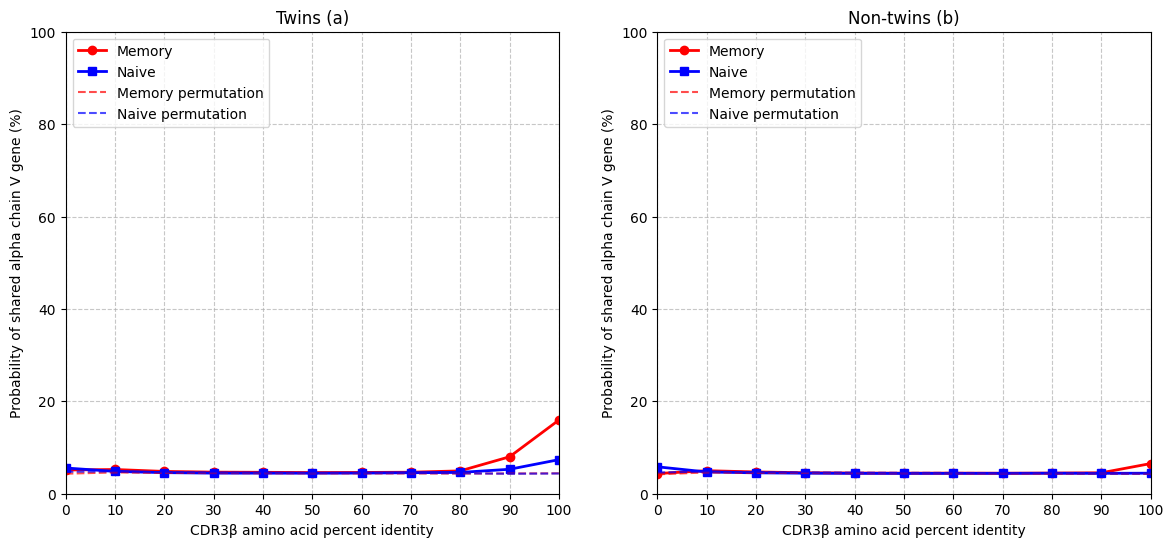

In [ ]:
# Calculate probabilities and prepare plot data
def prepare_plot_data(results, memory_permutation, naive_permutation):
    plot_data = {
        'memory': {
            'twin': {'x': [], 'y': []}, 
            'nontwin': {'x': [], 'y': []}, 
            'permutation_twin': {'x': [], 'y': [], 'err': []},
            'permutation_nontwin': {'x': [], 'y': [], 'err': []}
        },
        'naive': {
            'twin': {'x': [], 'y': []}, 
            'nontwin': {'x': [], 'y': []}, 
            'permutation_twin': {'x': [], 'y': [], 'err': []},
            'permutation_nontwin': {'x': [], 'y': [], 'err': []}
        }
    }
    
    # Process actual data
    for data_type in ['memory', 'naive']:
        for twin_status in ['twin', 'nontwin']:
            for bin_label in bin_labels:
                count = results[data_type][twin_status][bin_label]['count']
                sum_val = results[data_type][twin_status][bin_label]['sum']
                
                if count > 0:
                    probability = (sum_val / count) * 100
                    plot_data[data_type][twin_status]['x'].append(bin_label)
                    plot_data[data_type][twin_status]['y'].append(probability)
    
    # Process permutation data - calculate mean and standard deviation
    # First collect all permutation probability values for each bin_label
    memory_perm_probs = {'twin': {}, 'nontwin': {}}
    naive_perm_probs = {'twin': {}, 'nontwin': {}}
    
    # Initialize dictionaries to store all permutation results for each bin
    for bin_label in bin_labels:
        memory_perm_probs['twin'][bin_label] = []
        memory_perm_probs['nontwin'][bin_label] = []
        naive_perm_probs['twin'][bin_label] = []
        naive_perm_probs['nontwin'][bin_label] = []
    
    # Collect memory permutation data
    for perm_idx in memory_permutation:
        for twin_status in ['twin', 'nontwin']:
            for bin_label in bin_labels:
                if bin_label in memory_permutation[perm_idx][twin_status]:
                    count = memory_permutation[perm_idx][twin_status][bin_label]['count']
                    sum_val = memory_permutation[perm_idx][twin_status][bin_label]['sum']
                    if count > 0:
                        probability = (sum_val / count) * 100
                        memory_perm_probs[twin_status][bin_label].append(probability)
    
    # Collect naive permutation data
    for perm_idx in naive_permutation:
        for twin_status in ['twin', 'nontwin']:
            for bin_label in bin_labels:
                if bin_label in naive_permutation[perm_idx][twin_status]:
                    count = naive_permutation[perm_idx][twin_status][bin_label]['count']
                    sum_val = naive_permutation[perm_idx][twin_status][bin_label]['sum']
                    if count > 0:
                        probability = (sum_val / count) * 100
                        naive_perm_probs[twin_status][bin_label].append(probability)
    
    # Calculate mean and standard deviation
    for twin_status in ['twin', 'nontwin']:
        for bin_label in bin_labels:
            # Memory
            if memory_perm_probs[twin_status][bin_label]:
                mean_val = np.mean(memory_perm_probs[twin_status][bin_label])
                std_val = np.std(memory_perm_probs[twin_status][bin_label])
                plot_data['memory'][f'permutation_{twin_status}']['x'].append(bin_label)
                plot_data['memory'][f'permutation_{twin_status}']['y'].append(mean_val)
                plot_data['memory'][f'permutation_{twin_status}']['err'].append(std_val)
            
            # Naive
            if naive_perm_probs[twin_status][bin_label]:
                mean_val = np.mean(naive_perm_probs[twin_status][bin_label])
                std_val = np.std(naive_perm_probs[twin_status][bin_label])
                plot_data['naive'][f'permutation_{twin_status}']['x'].append(bin_label)
                plot_data['naive'][f'permutation_{twin_status}']['y'].append(mean_val)
                plot_data['naive'][f'permutation_{twin_status}']['err'].append(std_val)
    
    return plot_data

# Prepare plot data
plot_data = prepare_plot_data(results, memory_permutation, naive_permutation)

# Create charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Twins chart (a)
ax1.plot(plot_data['memory']['twin']['x'], plot_data['memory']['twin']['y'], 
         color='red', marker='o', label='Memory', linewidth=2)
ax1.plot(plot_data['naive']['twin']['x'], plot_data['naive']['twin']['y'], 
         color='blue', marker='s', label='Naive', linewidth=2)

# Add permutation results to twins chart
if plot_data['memory']['permutation_twin']['x']:
    ax1.plot(plot_data['memory']['permutation_twin']['x'], 
             plot_data['memory']['permutation_twin']['y'],
             linestyle='--', color='red', alpha=0.7, label='Memory permutation')
    # Optional: add error bars
    # ax1.fill_between(plot_data['memory']['permutation_twin']['x'],
    #                  np.array(plot_data['memory']['permutation_twin']['y']) - np.array(plot_data['memory']['permutation_twin']['err']),
    #                  np.array(plot_data['memory']['permutation_twin']['y']) + np.array(plot_data['memory']['permutation_twin']['err']),
    #                  color='red', alpha=0.2)
if plot_data['naive']['permutation_twin']['x']:
    ax1.plot(plot_data['naive']['permutation_twin']['x'], 
             plot_data['naive']['permutation_twin']['y'],
             linestyle='--', color='blue', alpha=0.7, label='Naive permutation')
    # Optional: add error bars
    # ax1.fill_between(plot_data['naive']['permutation_twin']['x'],
    #                 np.array(plot_data['naive']['permutation_twin']['y']) - np.array(plot_data['naive']['permutation_twin']['err']),
    #                 np.array(plot_data['naive']['permutation_twin']['y']) + np.array(plot_data['naive']['permutation_twin']['err']),
    #                 color='blue', alpha=0.2)

# Non-twins chart (b)
ax2.plot(plot_data['memory']['nontwin']['x'], plot_data['memory']['nontwin']['y'], 
         color='red', marker='o', label='Memory', linewidth=2)
ax2.plot(plot_data['naive']['nontwin']['x'], plot_data['naive']['nontwin']['y'], 
         color='blue', marker='s', label='Naive', linewidth=2)

# Add permutation results to non-twins chart
if plot_data['memory']['permutation_nontwin']['x']:
    ax2.plot(plot_data['memory']['permutation_nontwin']['x'], 
             plot_data['memory']['permutation_nontwin']['y'],
             linestyle='--', color='red', alpha=0.7, label='Memory permutation')
    # Optional: add error bars
    # ax2.fill_between(plot_data['memory']['permutation_nontwin']['x'],
    #                 np.array(plot_data['memory']['permutation_nontwin']['y']) - np.array(plot_data['memory']['permutation_nontwin']['err']),
    #                 np.array(plot_data['memory']['permutation_nontwin']['y']) + np.array(plot_data['memory']['permutation_nontwin']['err']),
    #                 color='red', alpha=0.2)
if plot_data['naive']['permutation_nontwin']['x']:
    ax2.plot(plot_data['naive']['permutation_nontwin']['x'], 
             plot_data['naive']['permutation_nontwin']['y'],
             linestyle='--', color='blue', alpha=0.7, label='Naive permutation')
    # Optional: add error bars
    # ax2.fill_between(plot_data['naive']['permutation_nontwin']['x'],
    #                 np.array(plot_data['naive']['permutation_nontwin']['y']) - np.array(plot_data['naive']['permutation_nontwin']['err']),
    #                 np.array(plot_data['naive']['permutation_nontwin']['y']) + np.array(plot_data['naive']['permutation_nontwin']['err']),
    #                 color='blue', alpha=0.2)

# Set chart properties
for ax, title in [(ax1, 'Twins (a)'), (ax2, 'Non-twins (b)')]:
    ax.set_xlabel('CDR3β amino acid percent identity')
    ax.set_ylabel('Probability of shared alpha chain V gene (%)')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xticks(bin_labels)
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left')
plt.savefig("/mnt/d/TCRMI/figures/twins/twins_nontwins_TRAV_identity.pdf", transparent=True)


In [ ]:
# Assume we already have saved HLA genotype data
# If you need to read from pickle file, uncomment the lines below
with open('results/twins/hla_genotype_data.pkl', 'rb') as f:
    subject_hla_data = pickle.load(f)

def count_shared_alleles(subject1, subject2, hla_type):
    """Count the number of shared HLA alleles between two subjects"""
    shared_count = 0
    
    # For HLA-I type, calculate shared alleles at A, B, C loci
    if hla_type == "HLA-I":
        for locus in ["A", "B", "C"]:
            # Get alleles for both subjects at current locus
            alleles1 = set(subject_hla_data[subject1][hla_type][locus])
            alleles2 = set(subject_hla_data[subject2][hla_type][locus])
            
            # Calculate number of shared alleles
            shared = alleles1.intersection(alleles2)
            shared_count += len(shared)
    
    # For HLA-II type, calculate shared alleles at DRB1, DRB3/4/5, DQB1 loci
    elif hla_type == "HLA-II":
        for locus in ["DRB1", "DRB3/4/5", "DQB1"]:
            # Get alleles for both subjects at current locus
            alleles1 = set(subject_hla_data[subject1][hla_type][locus])
            alleles2 = set(subject_hla_data[subject2][hla_type][locus])
            
            # Exclude "Blank" values
            if "Blank" in alleles1:
                alleles1.remove("Blank")
            if "Blank" in alleles2:
                alleles2.remove("Blank")
            
            # Calculate number of shared alleles
            shared = alleles1.intersection(alleles2)
            shared_count += len(shared)
    
    return shared_count

def count_shared_alleles(subject1, subject2, hla_type):
    """Count the number of shared HLA alleles between two subjects"""
    shared_count = 0
    
    # For HLA-I type, calculate shared alleles at A, B, C loci
    if hla_type == "HLA-I":
        for locus in ["A", "B", "C"]:
            # Get alleles for both subjects at current locus
            alleles1 = set(subject_hla_data[subject1][hla_type][locus])
            alleles2 = set(subject_hla_data[subject2][hla_type][locus])
            
            # Calculate number of shared alleles
            shared = alleles1.intersection(alleles2)
            shared_count += len(shared)
    
    # For HLA-II type, calculate shared alleles at DRB1, DRB3/4/5, DQB1 loci
    elif hla_type == "HLA-II":
        for locus in ["DRB1", "DRB3/4/5", "DQB1"]:
            # Get alleles for both subjects at current locus
            alleles1 = set(subject_hla_data[subject1][hla_type][locus])
            alleles2 = set(subject_hla_data[subject2][hla_type][locus])
            
            # Exclude "Blank" values
            if "Blank" in alleles1:
                alleles1.remove("Blank")
            if "Blank" in alleles2:
                alleles2.remove("Blank")
            
            # Calculate number of shared alleles
            shared = alleles1.intersection(alleles2)
            shared_count += len(shared)
    
    return shared_count

def is_twin_pair(subject1, subject2):
    """Determine if two subjects are a twin pair (same first letter of ID)"""
    return subject1[0] == subject2[0] and subject1 != subject2

# Initialize result dictionaries
result_hla_i = defaultdict(list)
result_hla_ii = defaultdict(list)

# Get all subject IDs
subject_ids = list(subject_hla_data.keys())

# Calculate shared allele counts between all non-twin subject pairs
for subject1, subject2 in itertools.combinations(subject_ids, 2):
    # Skip twin pairs
    if is_twin_pair(subject1, subject2):
        continue
    
    # Calculate HLA-I shared allele count
    shared_hla_i = count_shared_alleles(subject1, subject2, "HLA-I")
    # Add subject pair to corresponding HLA-I group
    result_hla_i[shared_hla_i].append((subject1, subject2))
    
    # Calculate HLA-II shared allele count
    shared_hla_ii = count_shared_alleles(subject1, subject2, "HLA-II")
    # Add subject pair to corresponding HLA-II group
    result_hla_ii[shared_hla_ii].append((subject1, subject2))

hla_shared_pairs = {
    "HLA-I_shared_alleles": dict(result_hla_i),
    "HLA-II_shared_alleles": dict(result_hla_ii)
}

# Define filter function
def should_exclude_subject(subject):
    """Determine if subject should be excluded (starts with D, E, F, X, Y, or Z)"""
    excluded_prefixes = ['D', 'E', 'F', 'X', 'Y', 'Z']
    return subject[0] in excluded_prefixes


## II_shared_alleles

In [ ]:
# Convert pairs to sets for fast lookup
hla_ii_pairs = {}
for shared_count, pairs in hla_shared_pairs['HLA-II_shared_alleles'].items():
    hla_ii_pairs[shared_count] = set()
    for pair in pairs:
        # Add both forward and reverse pairs to ensure lookup regardless of order
        hla_ii_pairs[shared_count].add((pair[0], pair[1]))
        hla_ii_pairs[shared_count].add((pair[1], pair[0]))

# Define 10 equally spaced intervals
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110]
bin_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # Use interval midpoints as labels

# Initialize result storage - only use one overall T cell category
allresults = {
    'total': {0: {}, 1: {}, 2:{}, 3:{}, 4:{}}
}

# Initialize counters for each bin
for shared_count in [0, 1, 2, 3, 4]:
    for bin_label in bin_labels:
        allresults['total'][shared_count][bin_label] = {'count': 0, 'sum': 0}


# Process individual file and update results
def process_file(file_path):
    try:
        print(f"Processing file: {file_path}")
        
        # Initialize results for current file
        file_results = {
            0: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            1: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            2: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            3: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            4: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels}
        }
        
        # Use more robust CSV reading with error handling options
        for chunk in pd.read_csv(file_path, 
                                chunksize=100000, 
                                error_bad_lines=False,  # Skip error lines
                                warn_bad_lines=True,    # Show warnings
                                low_memory=False,       # Avoid data type inference issues
                                quotechar='"',          # Explicitly specify quote character
                                escapechar='\\'):       # Specify escape character
            # Handle string values in CDRH3_identity column
            # Convert non-numeric values to NaN, then drop these rows
            chunk['CDRH3_identity'] = pd.to_numeric(chunk['CDRH3_identity'], errors='coerce')
            chunk = chunk.dropna(subset=['CDRH3_identity'])
            
            # Skip this chunk if no data remains after processing
            if chunk.empty:
                continue
            
            # Assign bins
            chunk['CDRH3_identity_bin'] = pd.cut(chunk['CDRH3_identity'], bins=bins, labels=bin_labels, right=False)
            
            # Determine HLA-II shared allele count
            def get_hla_ii_shared_count(row):
                donor_pair = (row['donor1'], row['donor2'])
                # Check if pair is in our HLA-II shared allele sets
                for count in [0, 1, 2, 3, 4]:
                    if donor_pair in hla_ii_pairs[count]:
                        return count
                return -1  # Not in our list
            
            # Add HLA-II shared allele count column
            chunk['hla_ii_shared'] = chunk.apply(get_hla_ii_shared_count, axis=1)
            
            # Process by bin and HLA-II shared allele count
            for bin_label in bin_labels:
                for shared_count in [0, 1, 2, 3, 4]:
                    # Process data for specific HLA-II shared allele count
                    hla_data = chunk[(~chunk['clonotype'])&(chunk['hla_ii_shared'] == shared_count) & (chunk['CDRH3_identity_bin'] == bin_label)]
                    if not hla_data.empty:
                        file_results[shared_count][bin_label]['count'] += len(hla_data)
                        file_results[shared_count][bin_label]['sum'] += hla_data['VL_same'].sum()
            
            # Free memory
            del chunk
        
        return file_results
    
    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")
        # Return empty results, don't affect processing of other files
        empty_results = {
            shared_count: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels}
            for shared_count in [0, 1, 2, 3, 4]
        }
        return empty_results


# Merge individual file results into total results
def merge_results(all_results, file_results):
    """Merge individual file results into total results"""
    for shared_count in [0, 1, 2, 3, 4]:
        for bin_label in bin_labels:
            all_results['total'][shared_count][bin_label]['count'] += file_results[shared_count][bin_label]['count']
            all_results['total'][shared_count][bin_label]['sum'] += file_results[shared_count][bin_label]['sum']

# Process multiple files sequentially (avoid complexity of parallel processing)
def process_files_sequential(file_paths):
    """Process multiple files sequentially"""
    print(f"Processing {len(file_paths)} files sequentially...")
    
    for file_path in file_paths:
        file_results = process_file(file_path)
        merge_results(allresults, file_results)

# Process multiple files in parallel (with more robust error handling)
def process_files_parallel(file_paths, n_processes=None):
    """Process multiple files in parallel"""
    if n_processes is None:
        n_processes = max(1, mp.cpu_count() - 1)  # Reserve one core for system
    
    print(f"Processing {len(file_paths)} files in parallel using {n_processes} processors...")
    
    # Create process pool
    pool = mp.Pool(processes=n_processes)
    
    # Use process pool for parallel processing with error handling
    try:
        file_results_list = pool.map(process_file, file_paths)
        
        # Close process pool
        pool.close()
        pool.join()
        
        # Merge results from all files
        for file_results in file_results_list:
            if file_results:  # Ensure results are not empty
                merge_results(allresults, file_results)
    
    except Exception as e:
        print(f"Error during parallel processing: {str(e)}")
        # Close process pool
        pool.close()
        pool.terminate()
        pool.join()
        
        # Fall back to sequential processing
        print("Falling back to sequential processing...")
        process_files_sequential(file_paths)


# First try sequential processing of first file to check for format issues
print("Testing processing of first file...")
all_files = glob.glob(os.path.join("results/twins/all_coherence", "*.csv"))

n_processes = max(1, mp.cpu_count() - 1)
process_files_parallel(all_files, n_processes)

In [ ]:
save_data(allresults, "/mnt/d/TCRMI/results/twins/II_shared_alleles.pickle")

In [16]:
allresults = pd.read_pickle("/mnt/d/TCRMI/results/twins/II_shared_alleles.pickle")

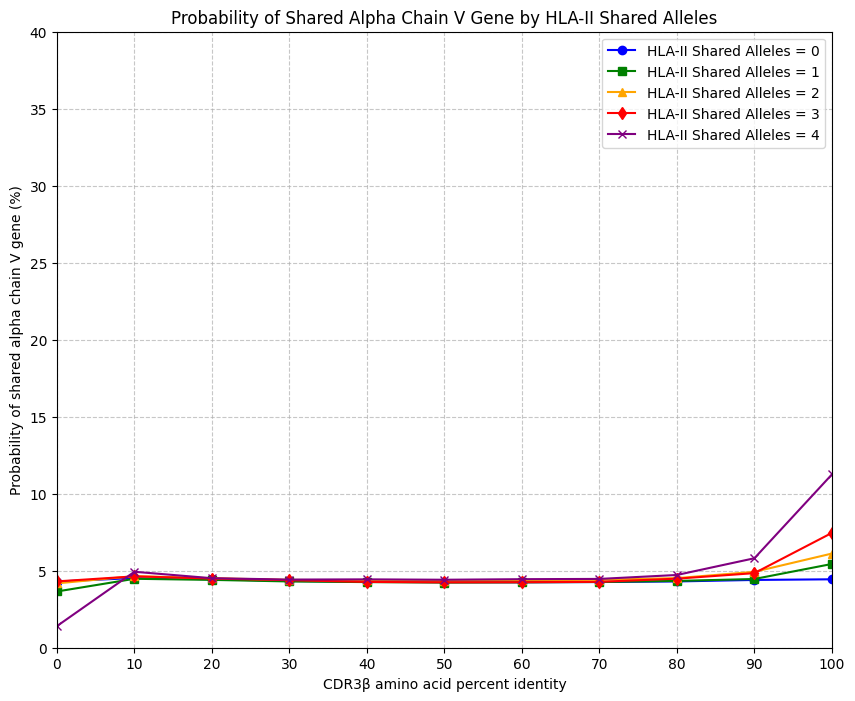

In [ ]:
def prepare_plot_data():
    plot_data = {
        'total': {0: {'x': [], 'y': []}, 
                  1: {'x': [], 'y': []}, 
                  2: {'x': [], 'y': []}, 
                  3: {'x': [], 'y': []}, 
                  4: {'x': [], 'y': []}}
    }
    
    for shared_count in [0, 1, 2, 3, 4]:
        for bin_label in bin_labels:
            count = allresults['total'][shared_count][bin_label]['count']
            sum_val = allresults['total'][shared_count][bin_label]['sum']
            
            if count > 0:
                probability = (sum_val / count) * 100
                plot_data['total'][shared_count]['x'].append(bin_label)
                plot_data['total'][shared_count]['y'].append(probability)
    
    return plot_data

# Prepare plot data
plot_data = prepare_plot_data()

# Can also create a single chart containing all HLA sharing counts for comparison
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
markers = ['o', 's', '^', 'd', 'x']

for i, shared_count in enumerate([0, 1, 2, 3, 4]):
    plt.plot(plot_data['total'][shared_count]['x'], plot_data['total'][shared_count]['y'], 
             color=colors[i], marker=markers[i], label=f'HLA-II Shared Alleles = {shared_count}')

plt.xlabel('CDR3β amino acid percent identity')
plt.ylabel('Probability of shared alpha chain V gene (%)')
plt.xlim(0, 100)
plt.ylim(0, 40)
plt.xticks(bin_labels)
plt.title('Probability of Shared Alpha Chain V Gene by HLA-II Shared Alleles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("/mnt/d/TCRMI/figures/twins/hla_ii_shared_alleles_subplots.pdf", transparent=True)


In [ ]:
# Convert pairs to sets for fast lookup
hla_ii_pairs = {}
for shared_count, pairs in hla_shared_pairs['HLA-I_shared_alleles'].items():
    hla_ii_pairs[shared_count] = set()
    for pair in pairs:
        # Add both forward and reverse pairs to ensure lookup regardless of order
        hla_ii_pairs[shared_count].add((pair[0], pair[1]))
        hla_ii_pairs[shared_count].add((pair[1], pair[0]))

# Define 10 equally spaced intervals
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110]
bin_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # Use interval midpoints as labels

# Initialize result storage - only use one overall T cell category
allresults = {
    'total': {0: {}, 1: {}, 2:{}, 3:{}}
}

# Initialize counters for each bin
for shared_count in [0, 1, 2, 3]:
    for bin_label in bin_labels:
        allresults['total'][shared_count][bin_label] = {'count': 0, 'sum': 0}


# Process individual file and update results
def process_file(file_path):
    try:
        print(f"Processing file: {file_path}")
        
        # Initialize results for current file
        file_results = {
            0: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            1: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            2: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
            3: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels},
        }
        
        # Use more robust CSV reading with error handling options
        for chunk in pd.read_csv(file_path, 
                                chunksize=100000, 
                                error_bad_lines=False,  # Skip error lines
                                warn_bad_lines=True,    # Show warnings
                                low_memory=False,       # Avoid data type inference issues
                                quotechar='"',          # Explicitly specify quote character
                                escapechar='\\'):       # Specify escape character
            # Handle string values in CDRH3_identity column
            # Convert non-numeric values to NaN, then drop these rows
            chunk['CDRH3_identity'] = pd.to_numeric(chunk['CDRH3_identity'], errors='coerce')
            chunk = chunk.dropna(subset=['CDRH3_identity'])
            
            # Skip this chunk if no data remains after processing
            if chunk.empty:
                continue
            
            # Assign bins
            chunk['CDRH3_identity_bin'] = pd.cut(chunk['CDRH3_identity'], bins=bins, labels=bin_labels, right=False)
            
            # Determine HLA-I shared allele count
            def get_hla_i_shared_count(row):
                donor_pair = (row['donor1'], row['donor2'])
                # Check if pair is in our HLA-I shared allele sets
                for count in [0, 1, 2, 3]:
                    if donor_pair in hla_ii_pairs[count]:
                        return count
                return -1  # Not in our list
            
            # Add HLA-I shared allele count column
            chunk['hla_i_shared'] = chunk.apply(get_hla_i_shared_count, axis=1)
            
            # Process by bin and HLA-I shared allele count
            for bin_label in bin_labels:
                for shared_count in [0, 1, 2, 3]:
                    # Process data for specific HLA-I shared allele count
                    hla_data = chunk[(~chunk['clonotype'])&(chunk['hla_i_shared'] == shared_count) & (chunk['CDRH3_identity_bin'] == bin_label)]
                    if not hla_data.empty:
                        file_results[shared_count][bin_label]['count'] += len(hla_data)
                        file_results[shared_count][bin_label]['sum'] += hla_data['VL_same'].sum()
            
            # Free memory
            del chunk
        
        return file_results
    
    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")
        # Return empty results, don't affect processing of other files
        empty_results = {
            shared_count: {bin_label: {'count': 0, 'sum': 0} for bin_label in bin_labels}
            for shared_count in [0, 1, 2, 3]
        }
        return empty_results


# Merge individual file results into total results
def merge_results(all_results, file_results):
    """Merge individual file results into total results"""
    for shared_count in [0, 1, 2, 3]:
        for bin_label in bin_labels:
            all_results['total'][shared_count][bin_label]['count'] += file_results[shared_count][bin_label]['count']
            all_results['total'][shared_count][bin_label]['sum'] += file_results[shared_count][bin_label]['sum']

# Process multiple files sequentially (avoid complexity of parallel processing)
def process_files_sequential(file_paths):
    """Process multiple files sequentially"""
    print(f"Processing {len(file_paths)} files sequentially...")
    
    for file_path in file_paths:
        file_results = process_file(file_path)
        merge_results(allresults, file_results)

# Process multiple files in parallel (with more robust error handling)
def process_files_parallel(file_paths, n_processes=None):
    """Process multiple files in parallel"""
    if n_processes is None:
        n_processes = max(1, mp.cpu_count() - 1)  # Reserve one core for system
    
    print(f"Processing {len(file_paths)} files in parallel using {n_processes} processors...")
    
    # Create process pool
    pool = mp.Pool(processes=n_processes)
    
    # Use process pool for parallel processing with error handling
    try:
        file_results_list = pool.map(process_file, file_paths)
        
        # Close process pool
        pool.close()
        pool.join()
        
        # Merge results from all files
        for file_results in file_results_list:
            if file_results:  # Ensure results are not empty
                merge_results(allresults, file_results)
    
    except Exception as e:
        print(f"Error during parallel processing: {str(e)}")
        # Close process pool
        pool.close()
        pool.terminate()
        pool.join()
        
        # Fall back to sequential processing
        print("Falling back to sequential processing...")
        process_files_sequential(file_paths)


# First try sequential processing of first file to check for format issues
print("Testing processing of first file...")
all_files = glob.glob(os.path.join("results/twins/all_coherence", "*.csv"))

n_processes = max(1, mp.cpu_count() - 1)
process_files_parallel(all_files, n_processes)
save_data(allresults, "/mnt/d/TCRMI/results/twins/I_shared_alleles.pickle")


In [12]:
allresults = pd.read_pickle("/mnt/d/TCRMI/results/twins/I_shared_alleles.pickle")

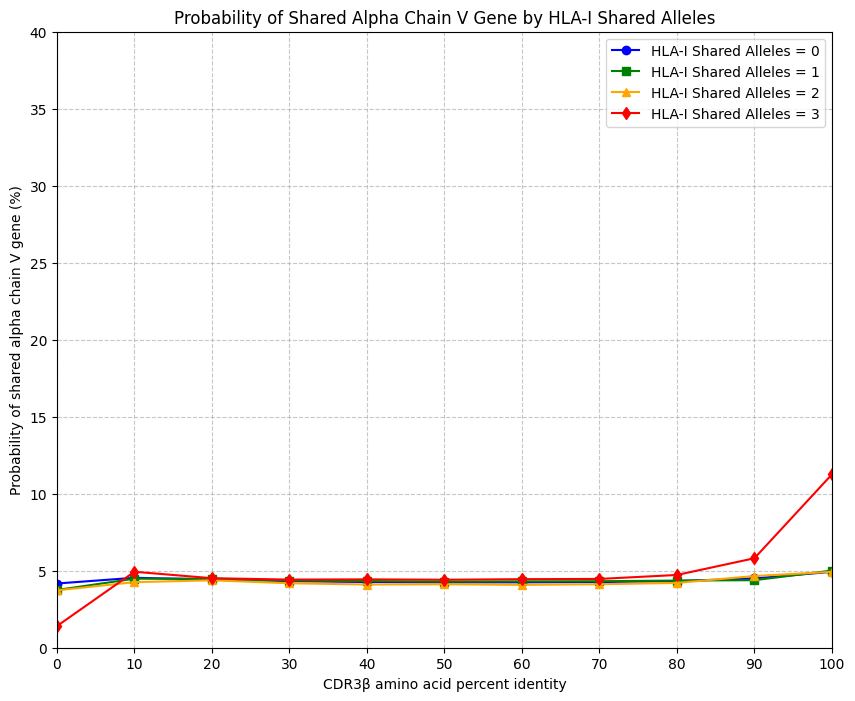

In [ ]:
def prepare_plot_data():
    plot_data = {
        'total': {0: {'x': [], 'y': []}, 
                  1: {'x': [], 'y': []}, 
                  2: {'x': [], 'y': []}, 
                  3: {'x': [], 'y': []},
                  }
    }
    
    for shared_count in [0, 1, 2, 3]:
        for bin_label in bin_labels:
            count = allresults['total'][shared_count][bin_label]['count']
            sum_val = allresults['total'][shared_count][bin_label]['sum']
            
            if count > 0:
                probability = (sum_val / count) * 100
                plot_data['total'][shared_count]['x'].append(bin_label)
                plot_data['total'][shared_count]['y'].append(probability)
    
    return plot_data

# Prepare plot data
plot_data = prepare_plot_data()

# Can also create a single chart containing all HLA sharing counts for comparison
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
markers = ['o', 's', '^', 'd', 'x']

for i, shared_count in enumerate([0, 1, 2, 3]):
    plt.plot(plot_data['total'][shared_count]['x'], plot_data['total'][shared_count]['y'], 
             color=colors[i], marker=markers[i], label=f'HLA-I Shared Alleles = {shared_count}')

plt.xlabel('CDR3β amino acid percent identity')
plt.ylabel('Probability of shared alpha chain V gene (%)')
plt.xlim(0, 100)
plt.ylim(0, 40)
plt.xticks(bin_labels)
plt.title('Probability of Shared Alpha Chain V Gene by HLA-I Shared Alleles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("/mnt/d/TCRMI/figures/twins/hla_i_shared_alleles_subplots.pdf", transparent=True)
